In [1]:
using Plots
include("../src/SOC_Controller.jl")

Main.SoCController

In [2]:
# Define simulation time-scale/steps
Δt = 2.5 # seconds
dt_min = Δt/(60) # convert ΔT from seconds to minutes
dt_hrs = Δt/(60*60) # convert ΔT from seconds to hours
T_begin = 9.0; # hours
T_end = 12.0; # hours 
ts_hrs = T_begin:dt_hrs:T_end # hours
ts_min = T_begin*60:dt_min:T_end*60

540.0:0.041666666666666664:720.0

# New Target SOC Profile Generation Proposal

In the ILC paper, we showed that there exists some constant speed that the boat can travel at across the year such that we maximize distance traveled while guaranteeing persistent operation. As such, in that paper, we showed that for any given day of the year, there is a nominal SOC profile that the boat can track at a constant speed (under an ideal irradiance profile). 

However, in practice, we do not have much control over the initial state of charge of the boat. We also have a significant time restriction on our mission (each mission is only about 3 hours long). As such, if the SOC of the boat at the current time is way off from the nominal profile (we'll assume for instance that we're high on SOC profile), our controller will tell us to travel at the maximum speed until we burn off enough energy to meet the nominal profile, which we may not have enough time to do during our shorter missions on the lake.

The nominal SOC profile for mid-summer looks like the plot below (where hr 12 = midnight). This profile has an associated nominal constant speed of about 1.8 m/s.

![nominal_soc_v_time.png](nominal_soc_v_time.png)

## The Old Implementation
In the original implementation, at the start of the mission we computed a target SOC profile to track with our PID-based speed controller based on the following parameters:
- Initial SOC (this is provided by the boat's current state)
- Terminal SOC (user-defined)
- Mission duration (user-defined)
- Current time of day (provided by boat/computer clock)

We then used the ILC formulation to converge on a target SOC profile that connected the intial and terminal SOC such that under an ideal irradiance profile, the boat would need to travel at a constant speed, which we tracked. The obvious pitfall of this method is that it requires good intuition from the user to determine a reasonable terminal SOC for the desired mission duration (and does not follow the nominal result in any way).

Below we show an implementation of the soc target profile generation and the speed when tracked by (a suboptimally tuned) PID controller. The speed converges to the nominal constant speed for that profile.

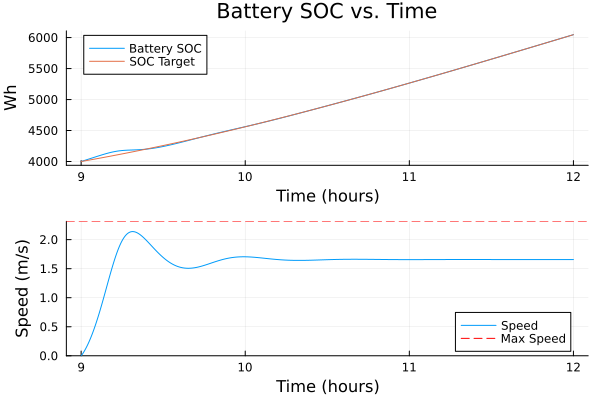

In [3]:
# Define the desired start and end SOC
soc_begin = 4000; # this would be provided by the boat's current state
soc_end = 6000; # user-defined
# T_begin = 9 AM is defined at the top of this notebook, this would be the time associated with starting the mission
# T_end = 12 PM is defined at the top of this notebook, this is a user-defined parameter for a 3 hour long mission


# Generate SOC Profile
lcbf = SoCController.compute_lcbf(ts_hrs, dt_hrs);
ucbf = SoCController.compute_ucbf(ts_hrs, dt_hrs);
soc_target = SoCController.generate_SOC_target(lcbf, ucbf,  soc_begin, soc_end, ts_hrs, dt_hrs);

# Simulate energy dynamics
error = 0.0;
error_sum = 0.0;
speeds = [Float64(0.0)];
bs = [Float64(soc_begin)];
dayOfYear = 91; # corresponds to April 1
lat = 35.45; # degrees - corresponds to Jordan Lake
boat = SoCController.ASV_Params();
ΔT = Base.step(ts_min)
for (it, t) in enumerate(ts_min[1:(end-1)])
    b = bs[end];
    global error_sum;
    global error;
    speed, error_sum, error = SoCController.speed_controller(b, soc_target[it], error_sum, error);
    push!(speeds, speed);
    push!(bs, SoCController.batterymodel!(boat, dayOfYear, t/60, lat, speed, b, ΔT/60))
end

# xticks = range(T_begin, stop=T_end, step=5/60) # 5 minutes in hours
socplot = plot(ts_hrs, bs, label="Battery SOC", title="Battery SOC vs. Time", ylabel="Wh", xlabel="Time (hours)")
socplot = plot!(ts_hrs, soc_target, label="SOC Target")

speed_plot = plot(ts_hrs, speeds, label="Speed", ylabel="Speed (m/s)", xlabel="Time (hours)", ylims=(boat.v_min, boat.v_max))
speed_plot = hline!([boat.v_max], label="Max Speed", color="red", linestyle=:dash)

plot(socplot, speed_plot, layout=(2,1))

We run the analysis again using different setpoints to illustrate the effect it has on the constant velocity:

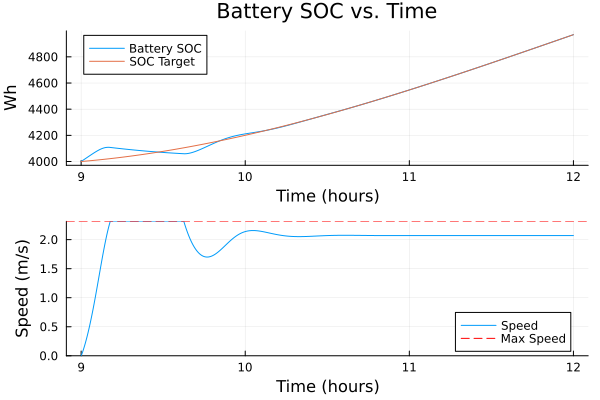

In [4]:
# Define the desired start and end SOC
soc_begin = 4000; # this would be provided by the boat's current state
soc_end = 5000; # user-defined
# T_begin = 9 AM is defined at the top of this notebook, this would be the time associated with starting the mission
# T_end = 12 PM is defined at the top of this notebook, this is a user-defined parameter for a 3 hour long mission


# Generate SOC Profile
lcbf = SoCController.compute_lcbf(ts_hrs, dt_hrs);
ucbf = SoCController.compute_ucbf(ts_hrs, dt_hrs);
soc_target = SoCController.generate_SOC_target(lcbf, ucbf,  soc_begin, soc_end, ts_hrs, dt_hrs);

# Simulate energy dynamics
error = 0.0;
error_sum = 0.0;
speeds = [Float64(0.0)];
bs = [Float64(soc_begin)];
dayOfYear = 91; # corresponds to April 1
lat = 35.45; # degrees - corresponds to Jordan Lake
boat = SoCController.ASV_Params();
ΔT = Base.step(ts_min)
for (it, t) in enumerate(ts_min[1:(end-1)])
    b = bs[end];
    global error_sum;
    global error;
    speed, error_sum, error = SoCController.speed_controller(b, soc_target[it], error_sum, error);
    push!(speeds, speed);
    push!(bs, SoCController.batterymodel!(boat, dayOfYear, t/60, lat, speed, b, ΔT/60))
end

# xticks = range(T_begin, stop=T_end, step=5/60) # 5 minutes in hours
socplot = plot(ts_hrs, bs, label="Battery SOC", title="Battery SOC vs. Time", ylabel="Wh", xlabel="Time (hours)")
socplot = plot!(ts_hrs, soc_target, label="SOC Target")

speed_plot = plot(ts_hrs, speeds, label="Speed", ylabel="Speed (m/s)", xlabel="Time (hours)", ylims=(boat.v_min, boat.v_max))
speed_plot = hline!([boat.v_max], label="Max Speed", color="red", linestyle=:dash)

plot(socplot, speed_plot, layout=(2,1))

## The new proposal

We modify the SOC generation function so it takes these parameters instead:
- Initial SOC (provided by the boat's current state)
- Mission duration (user-defined)
- Current time of day (provided by boat/computer clock)
- Desired constant speed (user-defined, but we can set it to the same value as the speed from the nominal year-long SOC trajectory above)


Given these parameters, we can simply forward propagate our model to determine what the target SOC profile would be under a nominal irradiance profile:

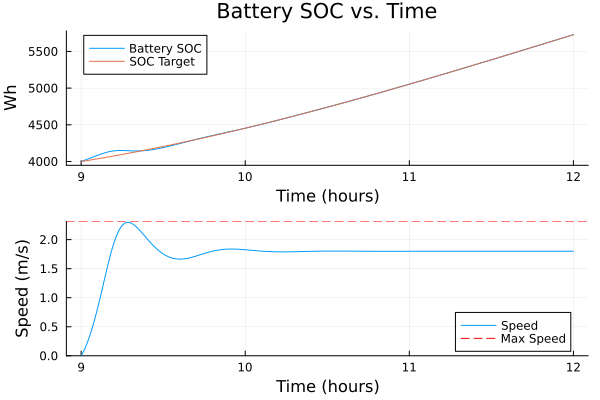

In [5]:
# Define the desired start SOC and constant speed
soc_begin = 4000.0; # this would be provided by the boat's current state
speed = 1.8; # user-defined (m/s)

# Generate Target SOC Profile
soc_target = [soc_begin];
dayOfYear = 91; # corresponds to April 1
lat = 35.45; # degrees - corresponds to Jordan Lake
boat = SoCController.ASV_Params();
ΔT = Base.step(ts_min)
for (it, t) in enumerate(ts_min[1:(end-1)])
    b = soc_target[end];
    push!(soc_target, SoCController.batterymodel!(boat, dayOfYear, t/60, lat, speed, b, ΔT/60))
end

# Simulate energy dynamics
error = 0.0;
error_sum = 0.0;
speeds = [Float64(0.0)];
bs = [Float64(soc_begin)];
dayOfYear = 91; # corresponds to April 1
lat = 35.45; # degrees - corresponds to Jordan Lake
boat = SoCController.ASV_Params();
ΔT = Base.step(ts_min)
for (it, t) in enumerate(ts_min[1:(end-1)])
    b = bs[end];
    global error_sum;
    global error;
    speed, error_sum, error = SoCController.speed_controller(b, soc_target[it], error_sum, error);
    push!(speeds, speed);
    push!(bs, SoCController.batterymodel!(boat, dayOfYear, t/60, lat, speed, b, ΔT/60))
end

# xticks = range(T_begin, stop=T_end, step=5/60) # 5 minutes in hours
socplot = plot(ts_hrs, bs, label="Battery SOC", title="Battery SOC vs. Time", ylabel="Wh", xlabel="Time (hours)")
socplot = plot!(ts_hrs, soc_target, label="SOC Target")

speed_plot = plot(ts_hrs, speeds, label="Speed", ylabel="Speed (m/s)", xlabel="Time (hours)", ylims=(boat.v_min, boat.v_max))
speed_plot = hline!([boat.v_max], label="Max Speed", color="red", linestyle=:dash)

plot(socplot, speed_plot, layout=(2,1))

We run the analysis again for the same constant speed but different starting SOC

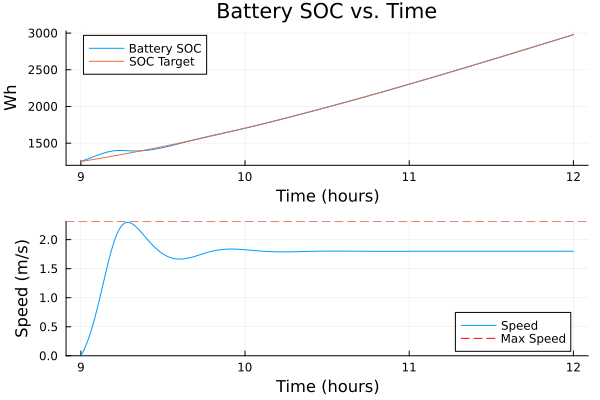

In [6]:
# Define the desired start SOC and constant speed
soc_begin = 1250.0; # this would be provided by the boat's current state
speed = 1.8; # user-defined (m/s)

# Generate Target SOC Profile
soc_target = [soc_begin];
dayOfYear = 91; # corresponds to April 1
lat = 35.45; # degrees - corresponds to Jordan Lake
boat = SoCController.ASV_Params();
ΔT = Base.step(ts_min)
for (it, t) in enumerate(ts_min[1:(end-1)])
    b = soc_target[end];
    push!(soc_target, SoCController.batterymodel!(boat, dayOfYear, t/60, lat, speed, b, ΔT/60))
end

# Simulate energy dynamics
error = 0.0;
error_sum = 0.0;
speeds = [Float64(0.0)];
bs = [Float64(soc_begin)];
dayOfYear = 91; # corresponds to April 1
lat = 35.45; # degrees - corresponds to Jordan Lake
boat = SoCController.ASV_Params();
ΔT = Base.step(ts_min)
for (it, t) in enumerate(ts_min[1:(end-1)])
    b = bs[end];
    global error_sum;
    global error;
    speed, error_sum, error = SoCController.speed_controller(b, soc_target[it], error_sum, error);
    push!(speeds, speed);
    push!(bs, SoCController.batterymodel!(boat, dayOfYear, t/60, lat, speed, b, ΔT/60))
end

# xticks = range(T_begin, stop=T_end, step=5/60) # 5 minutes in hours
socplot = plot(ts_hrs, bs, label="Battery SOC", title="Battery SOC vs. Time", ylabel="Wh", xlabel="Time (hours)")
socplot = plot!(ts_hrs, soc_target, label="SOC Target")

speed_plot = plot(ts_hrs, speeds, label="Speed", ylabel="Speed (m/s)", xlabel="Time (hours)", ylims=(boat.v_min, boat.v_max))
speed_plot = hline!([boat.v_max], label="Max Speed", color="red", linestyle=:dash)

plot(socplot, speed_plot, layout=(2,1))

We run the analysis for the same initial SOC but different constant speed setpoint

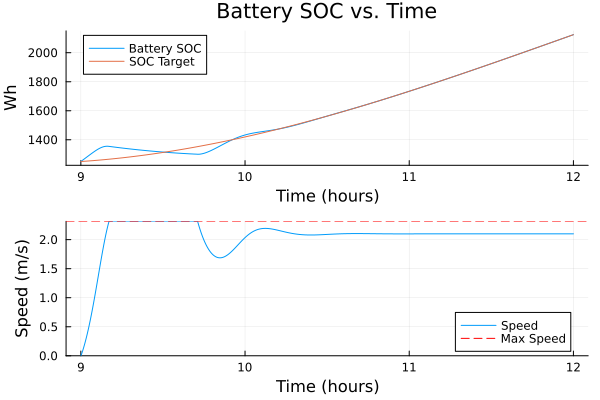

In [7]:
# Define the desired start SOC and constant speed
soc_begin = 1250.0; # this would be provided by the boat's current state
speed = 2.1; # user-defined (m/s)

# Generate Target SOC Profile
soc_target = [soc_begin];
dayOfYear = 91; # corresponds to April 1
lat = 35.45; # degrees - corresponds to Jordan Lake
boat = SoCController.ASV_Params();
ΔT = Base.step(ts_min)
for (it, t) in enumerate(ts_min[1:(end-1)])
    b = soc_target[end];
    push!(soc_target, SoCController.batterymodel!(boat, dayOfYear, t/60, lat, speed, b, ΔT/60))
end

# Simulate energy dynamics
error = 0.0;
error_sum = 0.0;
speeds = [Float64(0.0)];
bs = [Float64(soc_begin)];
dayOfYear = 91; # corresponds to April 1
lat = 35.45; # degrees - corresponds to Jordan Lake
boat = SoCController.ASV_Params();
ΔT = Base.step(ts_min)
for (it, t) in enumerate(ts_min[1:(end-1)])
    b = bs[end];
    global error_sum;
    global error;
    speed, error_sum, error = SoCController.speed_controller(b, soc_target[it], error_sum, error);
    push!(speeds, speed);
    push!(bs, SoCController.batterymodel!(boat, dayOfYear, t/60, lat, speed, b, ΔT/60))
end

# xticks = range(T_begin, stop=T_end, step=5/60) # 5 minutes in hours
socplot = plot(ts_hrs, bs, label="Battery SOC", title="Battery SOC vs. Time", ylabel="Wh", xlabel="Time (hours)")
socplot = plot!(ts_hrs, soc_target, label="SOC Target")

speed_plot = plot(ts_hrs, speeds, label="Speed", ylabel="Speed (m/s)", xlabel="Time (hours)", ylims=(boat.v_min, boat.v_max))
speed_plot = hline!([boat.v_max], label="Max Speed", color="red", linestyle=:dash)

plot(socplot, speed_plot, layout=(2,1))

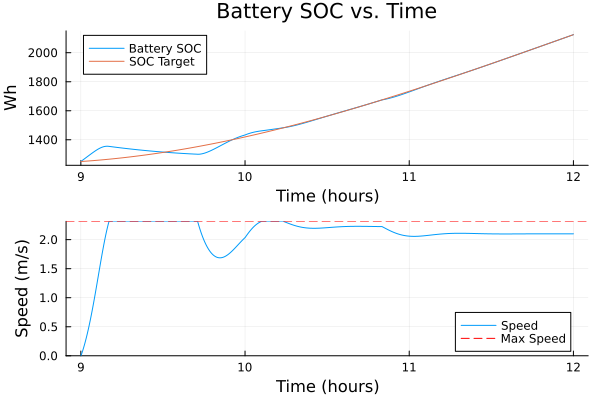

In [15]:
# Define the desired start SOC and constant speed
soc_begin = 1250.0; # this would be provided by the boat's current state
speed = 2.1; # user-defined (m/s)

# Generate Target SOC Profile
soc_target = [soc_begin];
dayOfYear = 91; # corresponds to April 1
lat = 35.45; # degrees - corresponds to Jordan Lake
boat = SoCController.ASV_Params();
ΔT = Base.step(ts_min)
for (it, t) in enumerate(ts_min[1:(end-1)])
    b = soc_target[end];
    push!(soc_target, SoCController.batterymodel!(boat, dayOfYear, t/60, lat, speed, b, ΔT/60))
end

# Simulate energy dynamics
error = 0.0;
error_sum = 0.0;
speeds = [Float64(0.0)];
bs = [Float64(soc_begin)];
dayOfYear = 91; # corresponds to April 1
lat = 35.45; # degrees - corresponds to Jordan Lake
boat = SoCController.ASV_Params();
ΔT = Base.step(ts_min)
for (it, t) in enumerate(ts_min[1:(end-1)])
    b = bs[end];
    global error_sum;
    global error;
    speed, error_sum, error = SoCController.speed_controller(b, soc_target[it], error_sum, error);
    push!(speeds, speed);
    if 600 <= t <= 650
        push!(bs, SoCController.batterymodel!(boat, dayOfYear, t/60, lat, speed, b, ΔT/60) + 0.1)
    else
        push!(bs, SoCController.batterymodel!(boat, dayOfYear, t/60, lat, speed, b, ΔT/60))
    end
end

# xticks = range(T_begin, stop=T_end, step=5/60) # 5 minutes in hours
socplot = plot(ts_hrs, bs, label="Battery SOC", title="Battery SOC vs. Time", ylabel="Wh", xlabel="Time (hours)")
socplot = plot!(ts_hrs, soc_target, label="SOC Target")

speed_plot = plot(ts_hrs, speeds, label="Speed", ylabel="Speed (m/s)", xlabel="Time (hours)", ylims=(boat.v_min, boat.v_max))
speed_plot = hline!([boat.v_max], label="Max Speed", color="red", linestyle=:dash)

plot(socplot, speed_plot, layout=(2,1))

In [9]:
ts_min

540.0:0.041666666666666664:720.0